<a href="https://colab.research.google.com/github/harshkdevr/nemi-ai-imaging/blob/main/Predicting%20Diabetes%20using%20Decision%20Tree%20Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading Required Libraries

In [3]:
# Loading Required Libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import tree

## Mounting Google Drive

In [2]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

data = pd.read_csv(url, names=columns)

pima = data

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Loading Diabetes Dataset from Google Drive

In [ ]:
# Loading Dataset
pima = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CSE4112 - ML Lab/diabetes.csv", encoding='utf8', engine='python')

# Exploring Dataset
pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Feature Selection

In [6]:
# Feature Selection
feature_cols = ['Pregnancies', 'Insulin', 'BMI', 'Age', 'Glucose', 'BloodPressure', 'DiabetesPedigreeFunction']

X = pima[feature_cols]
y = pima.Outcome

## Splitting Dataset into training and testing set

In [7]:
# Splitting Dataset into Training and Testing Set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% training and 20% test

## Building Decision Tree Classifer

In [8]:
# Creating Decision Tree Classifer Object
DT = DecisionTreeClassifier(criterion='entropy')

# Train Decision Tree Classifer
DT = DT.fit(X_train,y_train)

#Predict the Response for Test Dataset
y_pred = DT.predict(X_test)

## Displaying Accuracy of the Model

In [9]:
# Model Accuracy
print("Accuracy: ", round(accuracy_score(y_test, y_pred)*100, 2), "%")

Accuracy:  73.38 %


## Displaying the Decision Tree

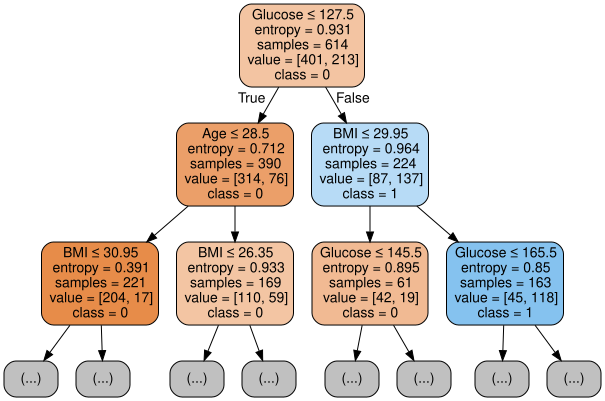

In [10]:
# Displaying decision tree
import graphviz
dot_data = tree.export_graphviz(DT, out_file=None,
                      max_depth = 2,
                      feature_names=feature_cols,
                      class_names=['0', '1'],
                      filled=True, rounded=True,
                      special_characters=True,)
graph = graphviz.Source(dot_data)
graph